In [1]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Flatten, Dense, Conv2D, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import os
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load the reshaped datasets
X_train_resized = np.load('/content/drive/MyDrive/PHYSIODATA/X_train_resized.npy')
X_test_resized = np.load('/content/drive/MyDrive/PHYSIODATA/X_test_resized.npy')
y_train = np.load('/content/drive/MyDrive/PHYSIODATA/y_train_resized.npy')
y_test = np.load('/content/drive/MyDrive/PHYSIODATA/y_test_resized.npy')

In [4]:
# Preprocess the data
X_train_resized = tf.keras.applications.vgg16.preprocess_input(np.repeat(X_train_resized, 3, axis=-1))
X_test_resized = tf.keras.applications.vgg16.preprocess_input(np.repeat(X_test_resized, 3, axis=-1))

In [7]:
# Define the ResNet50 model
from tensorflow.keras.applications import ResNet50


base_model_resNet = ResNet50(weights='imagenet', include_top=False, input_shape=(height, width, 3))
x = base_model_resNet.output
x = Flatten()(x)
x = Dense(64, activation='relu')(x)
predictions = Dense(5, activation='softmax')(x)
model_resNet = Model(inputs=base_model_resNet.input, outputs=predictions)

# Freeze the base model layers
for layer in base_model_resNet.layers:
    layer.trainable = False

# Compile the model
model_resNet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)
checkpoint_path = '/content/drive/MyDrive/PHYSIO2D/PHYSIOresnet.h5'
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max')

In [8]:
# Train and evaluate the model
history = model_resNet.fit(
    X_train_resized, y_train,
    epochs=400,
    batch_size=64,
    validation_data=(X_test_resized, y_test),
    callbacks=[checkpoint , early_stopping]
)

train_accuracy = model_resNet.evaluate(X_train_resized, y_train, verbose=0)[1]
test_accuracy = model_resNet.evaluate(X_test_resized, y_test, verbose=0)[1]

print(f"Training Accuracy: {train_accuracy}, Test Accuracy: {test_accuracy}")

Epoch 1/400
140/140 [==============================] - 12s 62ms/step - loss: 1.2541 - accuracy: 0.5262 - val_loss: 1.1321 - val_accuracy: 0.5745
Epoch 2/400
140/140 [==============================] - 5s 33ms/step - loss: 0.9574 - accuracy: 0.5830 - val_loss: 0.8522 - val_accuracy: 0.6134
Epoch 3/400
140/140 [==============================] - 5s 32ms/step - loss: 0.8969 - accuracy: 0.6055 - val_loss: 0.8813 - val_accuracy: 0.6160
Epoch 4/400
140/140 [==============================] - 4s 28ms/step - loss: 0.8651 - accuracy: 0.6239 - val_loss: 0.8619 - val_accuracy: 0.6114
Epoch 5/400
140/140 [==============================] - 5s 32ms/step - loss: 0.8295 - accuracy: 0.6361 - val_loss: 0.8566 - val_accuracy: 0.6165
Epoch 6/400
140/140 [==============================] - 5s 34ms/step - loss: 0.8174 - accuracy: 0.6459 - val_loss: 0.7923 - val_accuracy: 0.6448
Epoch 7/400
140/140 [==============================] - 4s 28ms/step - loss: 0.7846 - accuracy: 0.6508 - val_loss: 1.0179 - val_accuracy

In [9]:
from tensorflow.keras.models import load_model
model_path = '/content/drive/MyDrive/PHYSIO2D/PHYSIOresnet.h5'
loaded_model = load_model(model_path)

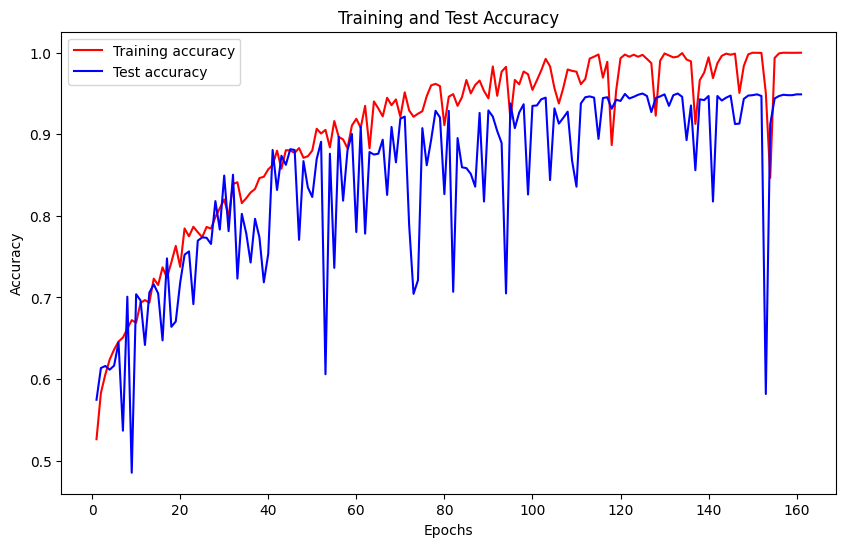

In [10]:
# Plot training and validation accuracies over epochs
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(acc) + 1)  # Number of epochs

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(epochs, acc, 'r', label='Training accuracy')  # 'bo' gives blue color and dot markers
plt.plot(epochs, val_acc, 'b', label='Test accuracy')   # 'b' gives solid blue line
plt.title('Training and Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# Generate predictions
y_pred = loaded_model.predict(X_test_resized)
y_pred_classes = np.argmax(y_pred, axis=1)

62/62 [==============================] - 2s 12ms/step


In [12]:
# Print classification report
class_report = classification_report(y_test, y_pred_classes)
print("\nClassification Report:\n", class_report)


Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93       185
           1       0.95      0.97      0.96      1137
           2       0.95      0.92      0.94       627
           3       0.97      0.93      0.95        30

    accuracy                           0.95      1979
   macro avg       0.95      0.94      0.94      1979
weighted avg       0.95      0.95      0.95      1979



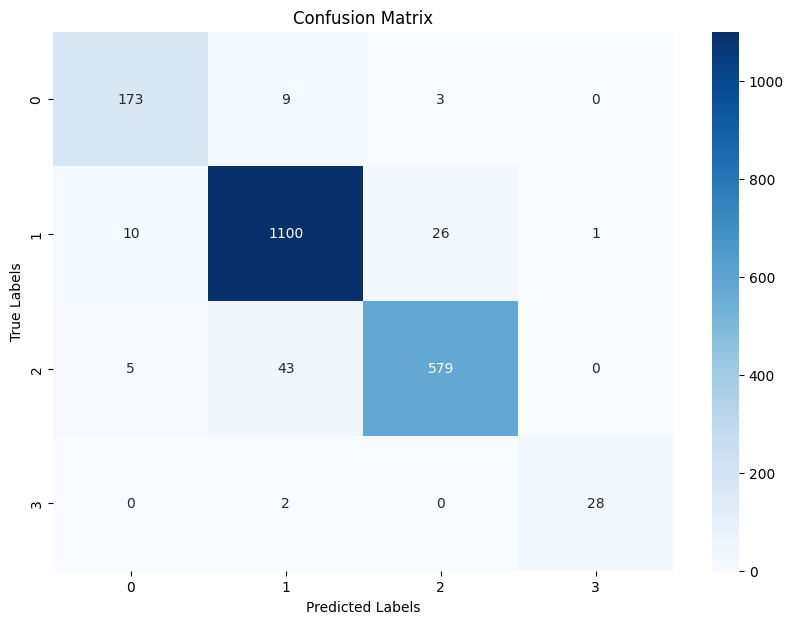

In [13]:
# Compute and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

62/62 [==============================] - 1s 12ms/step


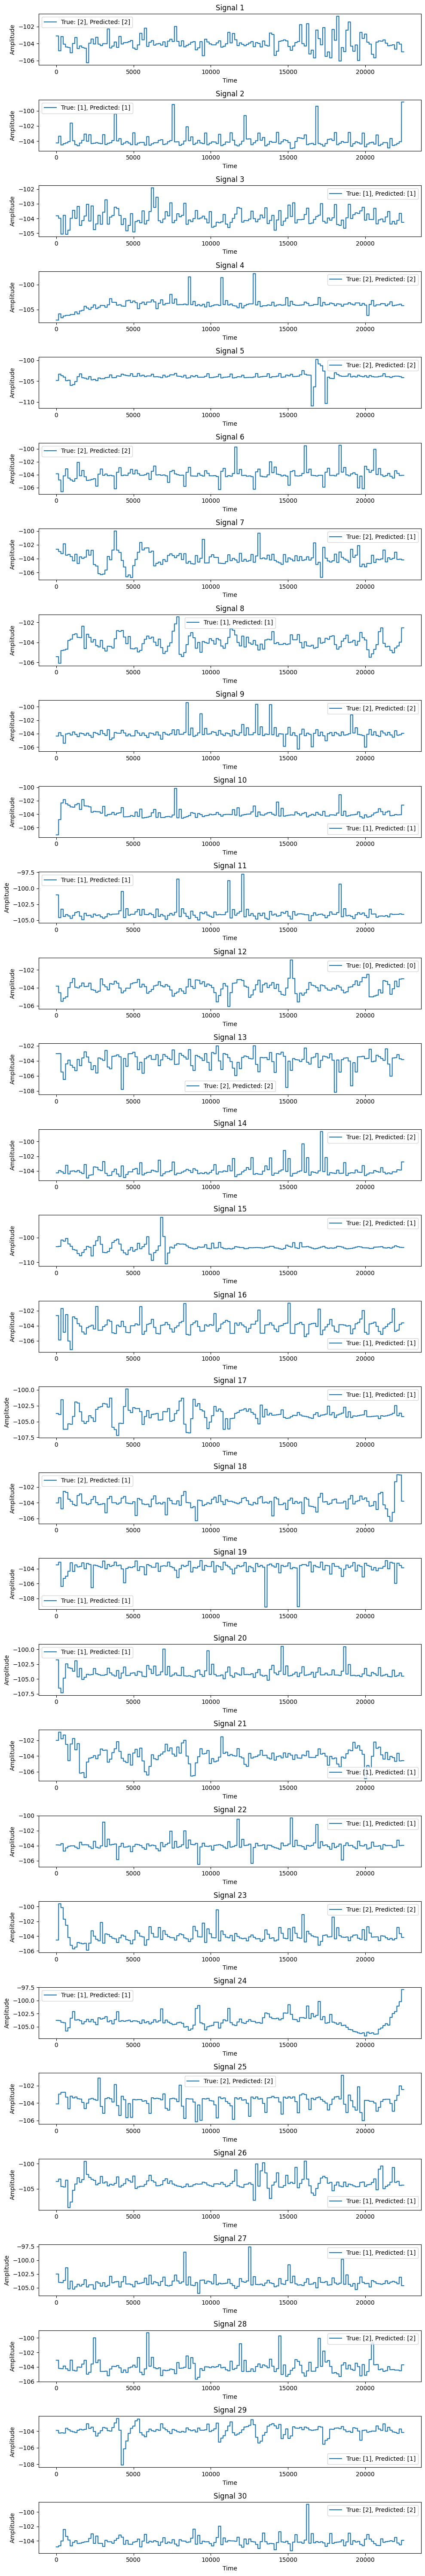

Correct Predictions: 1880
Incorrect Predictions: 99


In [14]:
# Plot sample signals with true and predicted labels, and display prediction accuracy
def plot_and_predict(X_test, y_test, model, num_samples=10, channel=0):

    # Ensure num_samples does not exceed length of X_test
    num_samples = min(num_samples, len(X_test))

    # Predict the labels
    predictions = model.predict(X_test)
    predicted_labels = np.argmax(predictions, axis=1)

    # Count correct and incorrect predictions
    correct = np.sum(predicted_labels == y_test)
    incorrect = len(y_test) - correct



    # Start plotting
    fig, axes = plt.subplots(num_samples, 1, figsize=(10, num_samples * 2))
    if num_samples == 1:
        axes = [axes]  # Make it iterable

    for i, ax in enumerate(axes):
        signal = X_test[i, :, :, channel].flatten()  # Flatten to 1D for plotting
        true_label = [y_test[i]]
        predicted_label = [predicted_labels[i]]
        ax.plot(signal, label=f'True: {true_label}, Predicted: {predicted_label}')
        ax.legend()
        ax.set_title(f'Signal {i+1}')
        ax.set_xlabel('Time')
        ax.set_ylabel('Amplitude')

    plt.tight_layout()
    plt.show()

    print(f"Correct Predictions: {correct}")
    print(f"Incorrect Predictions: {incorrect}")


plot_and_predict(X_test_resized, y_test, loaded_model, num_samples=30)